In [1]:
import numpy as np
import matplotlib.pyplot as plt

from spc import SPC3

In [100]:
spad_dir = r'C:\Users\SPUD1\Documents\experiment_workspace\SPAD data\spc3'

spad_file = 'spc3_snap_20260430-111806-739293.spc3' #50 mW
spad_file = 'spc3_snap_20260430-112157-274262.spc3' #60 mW
spad_file = 'spc3_snap_20260430-114204-988805.spc3' #70 mW

bg_file = 'spc3_snap_background_20260430-101031-849959.spc3'

frames, header = SPC3.ReadSPC3DataFile(f'{spad_dir}/{spad_file}')
frames = frames[0].astype(np.float64)  # (n_frames, n_cols, n_rows)
frames_bg, header_bg = SPC3.ReadSPC3DataFile(f'{spad_dir}/{bg_file}')
frames_bg = frames_bg[0].astype(np.float64)  # (n_frames, n_cols, n_rows)

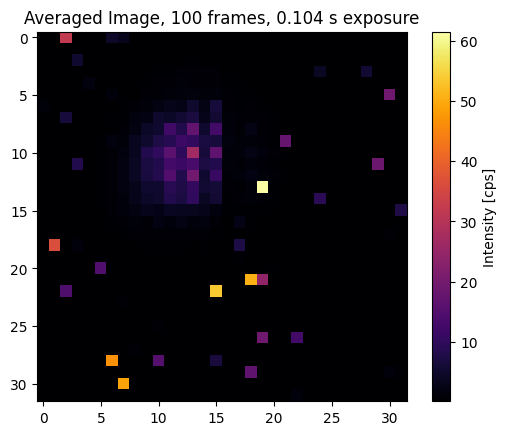

In [101]:
exposure_time_s = header.SummedFrames *header.HwIntTime
im_avg = frames.mean(axis=0)/exposure_time_s 

plt.imshow(im_avg/1e3, cmap='inferno')
plt.colorbar(label='Intensity [cps]')
plt.title('Averaged Image, {} frames, {:.3f} s exposure'.format(frames.shape[0], exposure_time_s))
plt.show()

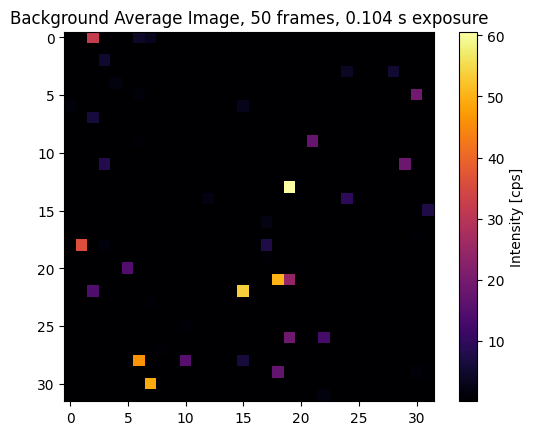

In [102]:
exposure_time_s = header_bg.SummedFrames *header_bg.HwIntTime
bg_avg = frames_bg.mean(axis=0)/exposure_time_s 

plt.imshow(bg_avg/1e3, cmap='inferno')
plt.colorbar(label='Intensity [cps]')
plt.title('Background Average Image, {} frames, {:.3f} s exposure'.format(frames_bg.shape[0], exposure_time_s))
plt.show()

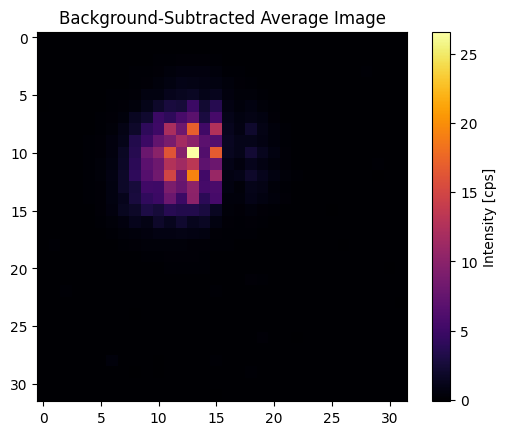

In [103]:
im_avg_bgsub = im_avg - bg_avg

plt.imshow(im_avg_bgsub/1e3, cmap='inferno')
plt.colorbar(label='Intensity [cps]')
plt.title('Background-Subtracted Average Image')
plt.show()

Brightest pixel at (row, col): (10, 13), intensity: 26606.63 cps


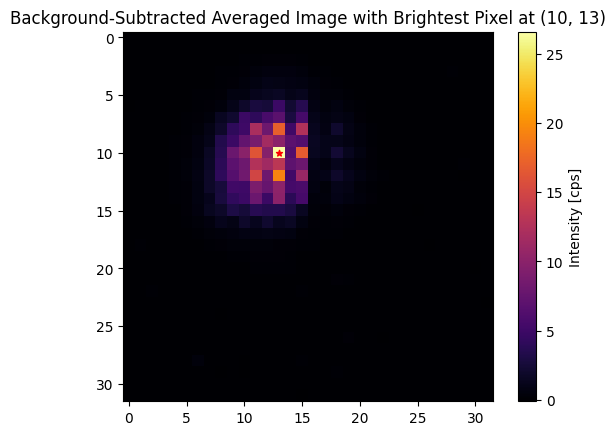

In [104]:
#find brightest pixel
brightest_pixel = np.unravel_index(np.argmax(im_avg_bgsub), im_avg_bgsub.shape)
print(f'Brightest pixel at (row, col): {brightest_pixel}, intensity: {im_avg_bgsub[brightest_pixel]:.2f} cps')

plt.imshow(im_avg_bgsub/1e3, cmap='inferno')
plt.colorbar(label='Intensity [cps]')
plt.title('Background-Subtracted Averaged Image with Brightest Pixel at {}'.format(brightest_pixel))
plt.scatter(brightest_pixel[1], brightest_pixel[0], color='red', marker='*', s=20, label='Brightest Pixel')
plt.show()

In [105]:
# Sum of the 9 brightest pixels vs the rest (on the averaged, background-subtracted frame)
img = np.asarray(im_avg_bgsub)
n_bright = 9
n_bright = min(n_bright, img.size)

flat = img.ravel()
top_idx = np.argpartition(flat, -n_bright)[-n_bright:]
top_vals = flat[top_idx]

# Sort top pixels by intensity (descending)
order = np.argsort(top_vals)[::-1]
top_idx = top_idx[order]
top_vals = top_vals[order]
top_coords = list(zip(*np.unravel_index(top_idx, img.shape)))

sum_top = float(np.sum(top_vals))
sum_total = float(np.sum(flat))
sum_rest = sum_total - sum_top

ratio_top_to_rest = (sum_top / sum_rest) if sum_rest != 0 else np.nan

print(f"Top {n_bright} pixels (row, col) and intensity [cps]:")
for (r, c), v in zip(top_coords, top_vals):
    print(f"  ({r:4d}, {c:4d}) : {v:,.2f}")

print("")
print(f"Sum top {n_bright} pixels: {sum_top:,.2f} cps")
print(f"Sum rest of frame (excluding top {n_bright}): {sum_rest:,.2f} cps")
print(f"Ratio (top {n_bright}) / (rest): {ratio_top_to_rest:.6g}")

Top 9 pixels (row, col) and intensity [cps]:
  (  10,   13) : 26,606.63
  (  12,   13) : 19,334.90
  (   8,   13) : 17,058.27
  (  10,   15) : 16,757.50
  (  10,   11) : 16,229.90
  (  12,   11) : 14,877.31
  (  11,   13) : 13,258.37
  (  11,   11) : 12,622.21
  (   8,   15) : 12,597.50

Sum top 9 pixels: 149,342.60 cps
Sum rest of frame (excluding top 9): 506,510.38 cps
Ratio (top 9) / (rest): 0.294846
